In [1]:
from typing import List, TypedDict
from langgraph.graph import StateGraph

In [7]:
class AgentState(TypedDict):
    """State of the agent."""
    name: str
    age: int
    skills: List[str]
    output: str

In [8]:
def personalise_name(state: AgentState) -> AgentState:
    """Personalise the user's name."""
    state["output"] = f"{state['name']}, it's great to meet you!"
    return state
def state_age(state: AgentState) -> AgentState:
    """State the user's age."""
    state["output"] += f" I see you are {state['age']} years old."
    return state
def list_skills(state: AgentState) -> AgentState:
    """List the user's skills."""
    if state["skills"]:
        state["output"] += f" You have skills in: {', '.join(state['skills'])}."
    else:
        state["output"] += " You have no listed skills."
    return state


In [9]:
graph = StateGraph(AgentState)

graph.add_node("personalise_name", personalise_name)
graph.add_node("state_age", state_age)
graph.add_node("list_skills", list_skills)

graph.add_edge("personalise_name", "state_age")
graph.add_edge("state_age", "list_skills")
graph.set_entry_point("personalise_name")
graph.set_finish_point("list_skills")

app = graph.compile()

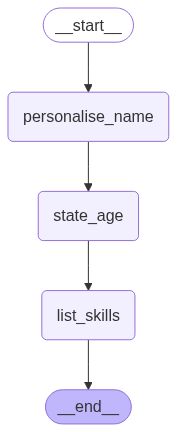

In [10]:
from IPython.display import display, Image
display(Image(app.get_graph().draw_mermaid_png())) 

In [11]:
app.invoke(AgentState(
    name="Alice",
    age=30,
    skills=["Python", "Data Analysis"],
    output=""
))['output']

"Alice, it's great to meet you! I see you are 30 years old. You have skills in: Python, Data Analysis."